In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1741000          1                      72                       56   
1  30579330          0                      70                       57   
2  40447085          1                      69                       67   
3  40451275          1                      41                       45   
4  40328563          1                      48                       44   

   team0_team_total_networth  team0_team_total_damage  \
0                     237513                   208358   
1                     244464                   227340   
2                     289685                   246054   
3                     251352                   176229   
4                     247987                   172154   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                             30484             25.166667   
1                             16059             33.333333   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    3240
0    3075
Name: count, dtype: int64
team0_won
1    0.513064
0    0.486936
Name: proportion, dtype: float64


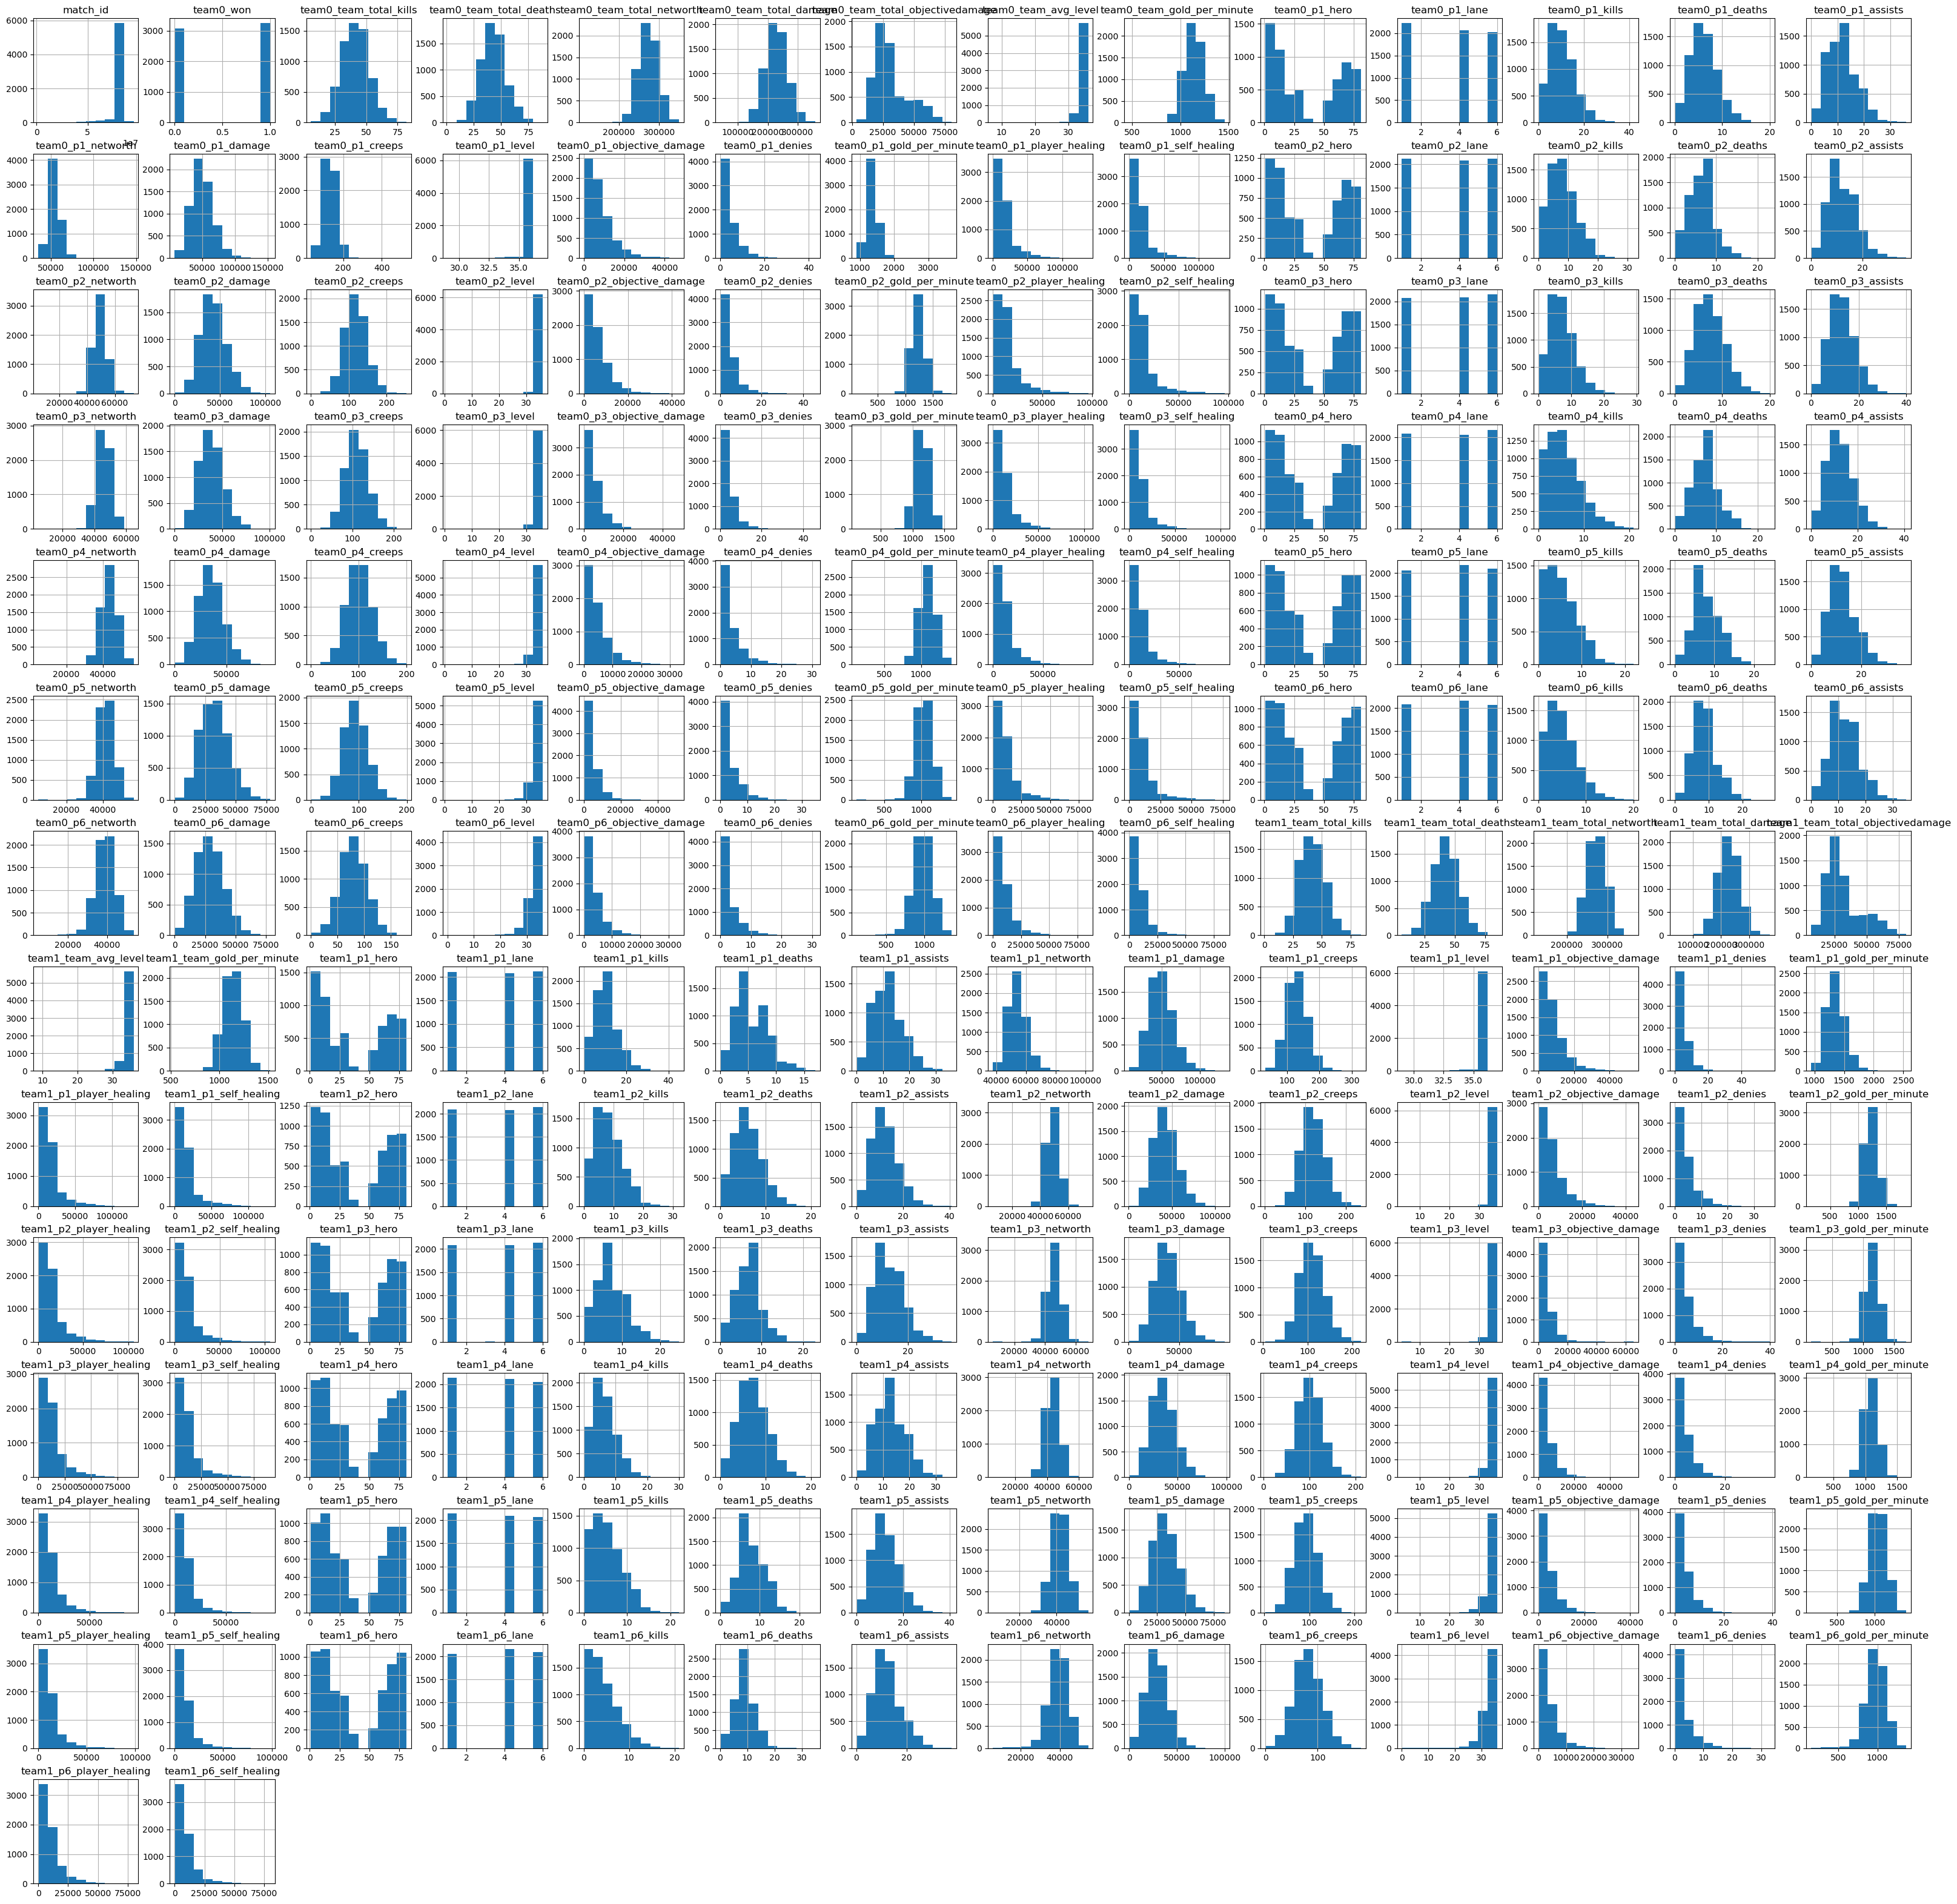

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count      6315.000000
mean     273059.060649
std       23657.269858
min      112575.000000
25%      256693.000000
50%      273234.000000
75%      289464.500000
max      349754.000000
Name: team0_team_total_networth, dtype: float64


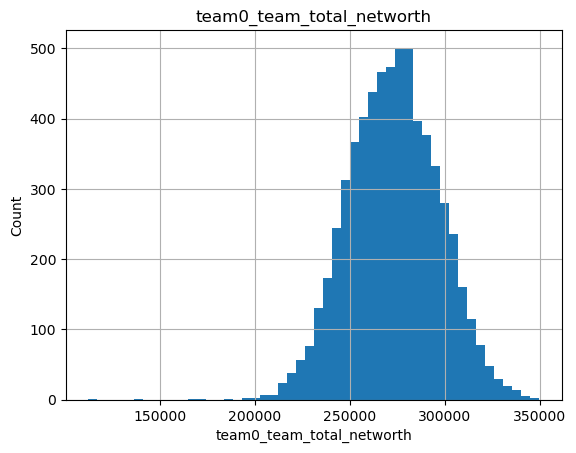

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [7]:
threshold = 175000

count = (df["team0_team_total_networth"] < threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] < 175000]

print((outliers.head(20)))

4
      match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
109   56386556          0                      19                       51   
1581  82180071          1                       7                        9   
5889  83232216          1                      35                        1   
5959  83239773          0                      10                        8   

      team0_team_total_networth  team0_team_total_damage  \
109                      169031                   139077   
1581                     140236                    51519   
5889                     170203                   148221   
5959                     112575                    39753   

      team0_team_total_objectivedamage  team0_team_avg_level  \
109                              15105             24.833333   
1581                             43865             15.000000   
5889                             17275              7.333333   
5959                             25384            

# Inspecting Correlations

In [8]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                           1.000000
team0_team_gold_per_minute          0.472168
team0_team_total_networth           0.471968
team0_team_total_objectivedamage    0.448479
team0_p4_gold_per_minute            0.423024
                                      ...   
team1_p4_networth                  -0.423611
team1_p4_gold_per_minute           -0.424326
team1_team_total_objectivedamage   -0.454208
team1_team_total_networth          -0.485932
team1_team_gold_per_minute         -0.486769
Name: team0_won, Length: 184, dtype: float64
